## Operaciones morfológicas

In [19]:
#Si queremos que las imágenes sean mostradas en una ventana emergente quitar el inline

# OpenCV-Python utiliza NumPy para el manejo de imágenes
import numpy as np
# cv2 es el módulo python para acceder a OpenCV 
import cv2 as cv
import supervision as sv

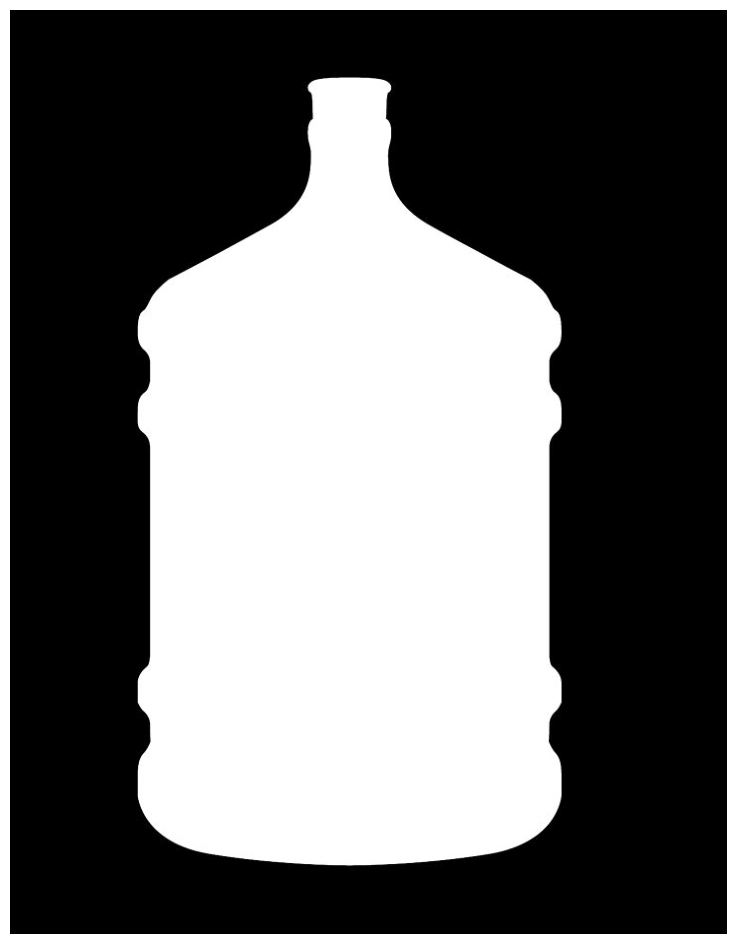

In [20]:
# Leemos la imagen
#=================
img = cv.imread('bidon.jpg', 0)
img = cv.bitwise_not(img)
sv.plot_image(img)

#### Erosión

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


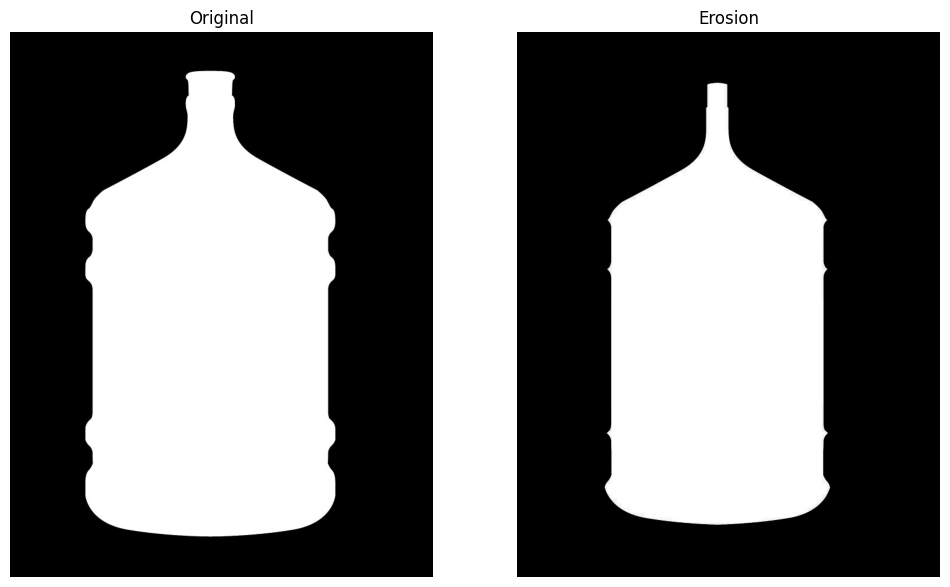

In [22]:
se = np.ones((5, 5), np.uint8)
print(se)
# o tambien 
# se = cv.getStructuringElement(cv.MORPH_RECT, (5, 5))
# otra oposibilidad pcion es usar un elemento con forma arbitraria,
# por ejemplo una cruz
# se = cv.getStructuringElement(cv.MORPH_CROSS, (5, 5))
# o armando el elemento a mano
# elem_struc = [[0, 1, 0],
#               [1, 1, 1],
#               [0, 1, 0]]
# se = np.ones((10,2), np.uint8)
erosion = cv.erode(img, se, iterations = 10)

sv.plot_images_grid(images=[img, erosion], grid_size=(1, 2), titles=['Original', 'Erosion'])

#### Dilatación

Elemento estructurante: [[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


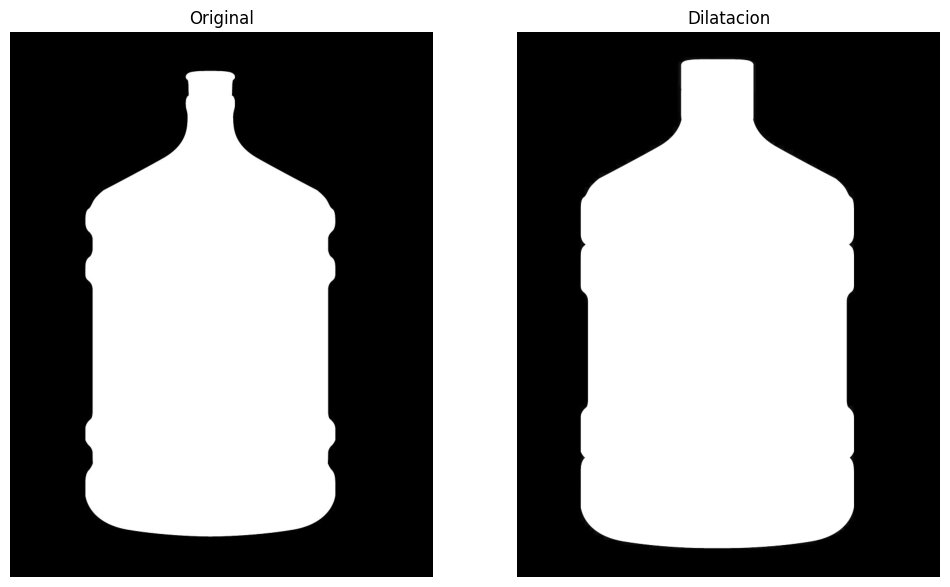

In [23]:
se = np.ones((5,5), np.uint8)

print(f'Elemento estructurante: {se}')

dilatacion = cv.dilate(img, se, iterations = 10)

sv.plot_images_grid(images=[img, dilatacion], grid_size=(1, 2), titles=['Original', 'Dilatacion'])

#### Apertura

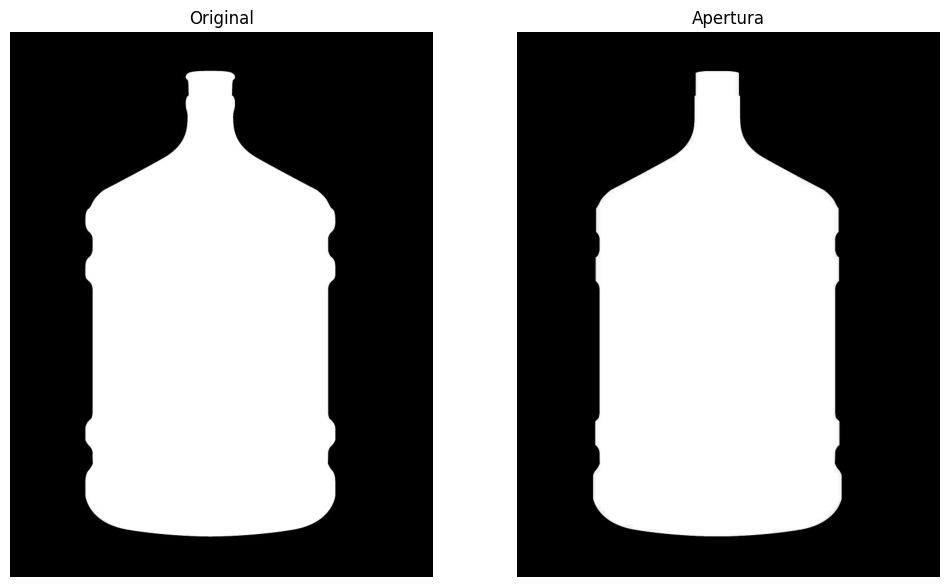

In [24]:
kernel = np.ones((5,5), np.uint8)
apertura = cv.morphologyEx(img, cv.MORPH_OPEN, kernel, iterations=10)

sv.plot_images_grid(images=[img, apertura], grid_size=(1, 2), titles=['Original', 'Apertura'])

#### Cierre

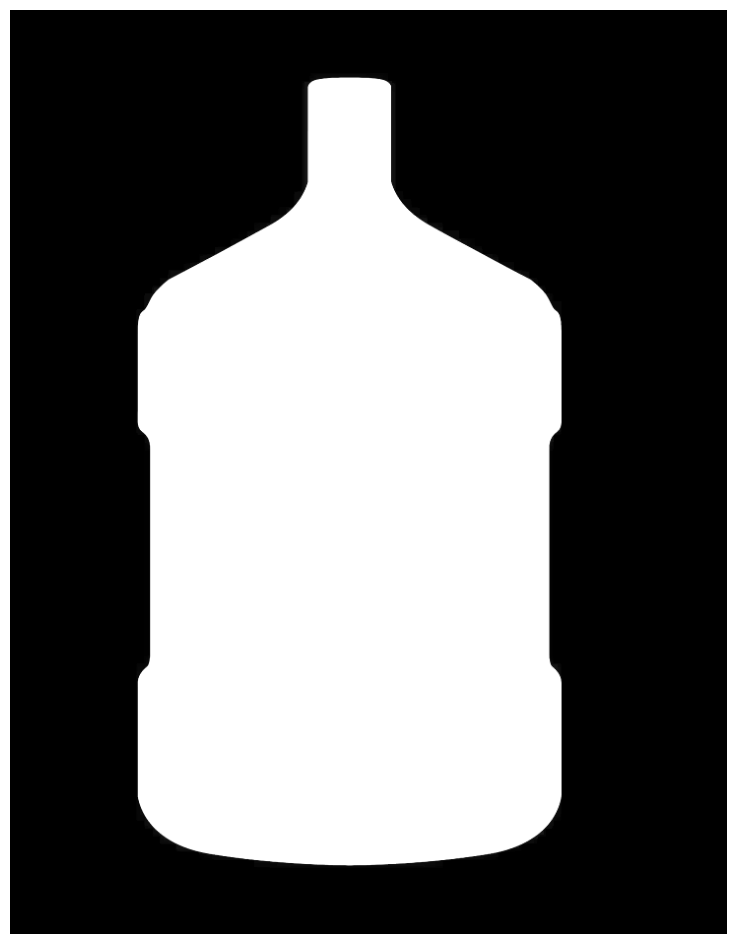

In [25]:
kernel = np.ones ((7,7), np.uint8)
cierre = cv.morphologyEx(img, cv.MORPH_CLOSE, kernel, iterations=20)

sv.plot_image(cierre)

#### Bordes

Utilización de erosión para recuperación de bordes

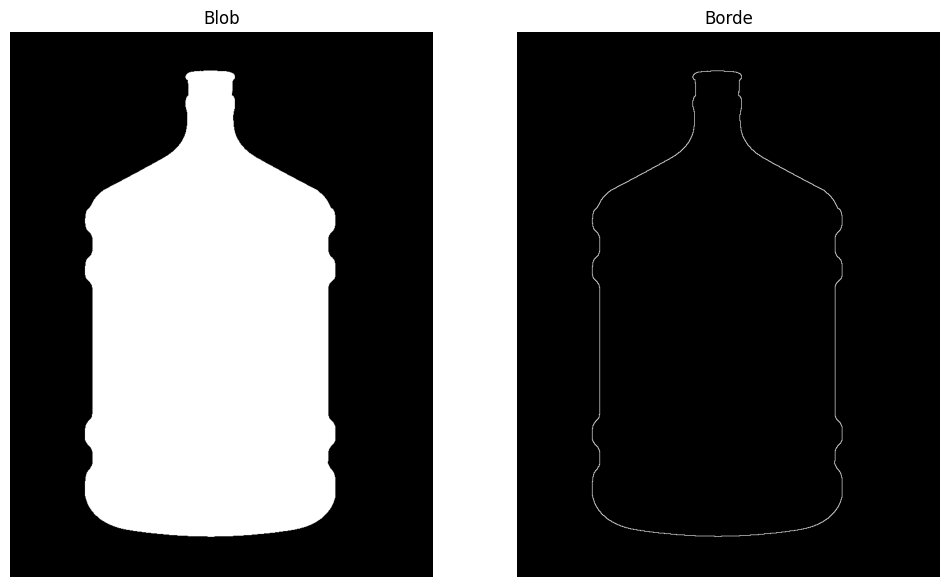

In [26]:
# Leemos la imagen
img = cv.imread('bidon.jpg',0)

ret, img_bin = cv.threshold(img,200,255,cv.THRESH_BINARY)

img_bin = cv.bitwise_not(img_bin)

# Erosionamos
kernel = np.ones ((3,3), np.uint8)
erosion = cv.erode (img_bin, kernel, iterations = 1)

# Restamos a la imagen original
borde = img_bin - erosion

sv.plot_images_grid(images=[img_bin, borde], grid_size=(1, 2), titles=['Blob', 'Borde'])


#### Apertura + Cierre

[[0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]]


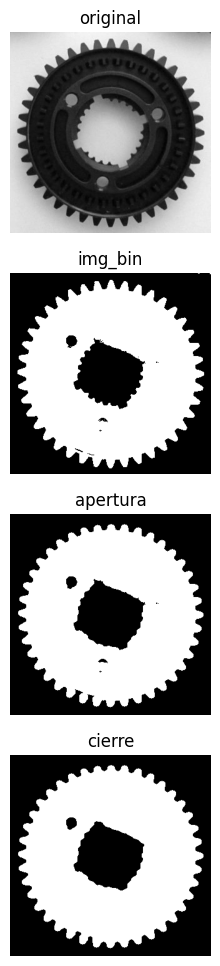

In [27]:
# Leemos la imagen
img = cv.imread('engranaje.jpg',0)

# Binarizamos
ret, img_bin = cv.threshold(img, 30, 255, cv.THRESH_BINARY+cv.THRESH_OTSU)
# ret, img_bin = cv.threshold(img,80,255,cv.THRESH_BINARY)

img_bin = cv.bitwise_not(img_bin)

# Abrimos
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (11, 11))
apertura = cv.morphologyEx(img_bin, cv.MORPH_OPEN, kernel, 6)

print(kernel)

# Cerramos
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7,7))
cierre = cv.morphologyEx(apertura, cv.MORPH_CLOSE, kernel)

sv.plot_images_grid(
    [img, img_bin, apertura, cierre], grid_size=(4, 1), 
    titles=["original", "img_bin", "apertura", "cierre"])